In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
# from google.colab import drive

# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set the path to the image dataset folder
dataset_path = 'C:/Users/nisri/Downloads/capstone/sigma-onion-sensor/analyzeAI/Training_ov5'

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the class labels
class_labels = ['Moler', 'Purple blotch', 'Healthy']
num_classes = len(class_labels)

# Image Data Generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# No augmentation for the validation data, just rescaling
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Generate training and validation batches from directories
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),  # Adjusted for VGG16
    batch_size=32,
    class_mode='sparse',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),  # Adjusted for VGG16
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)

# Print class indices to ensure consistent label mapping
print("Class indices for training data:", train_generator.class_indices)
print("Class indices for validation data:", validation_generator.class_indices)

Found 360 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Class indices for training data: {'healthy': 0, 'moler': 1, 'purple blotch': 2}
Class indices for validation data: {'healthy': 0, 'moler': 1, 'purple blotch': 2}


In [ ]:
# Load VGG16 pre-trained model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Adding custom layers on top of VGG16
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# This is the model we will train
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(lr=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

58889256/58889256 [==============================] - 3s 0us/step


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=50,  # You can adjust epochs based on your observation
    validation_data=validation_generator
)

Epoch 1/50
12/12 [==============================] - 319s 26s/step - loss: 1.0175 - accuracy: 0.5167 - val_loss: 1.0115 - val_accuracy: 0.5667
Epoch 2/50
12/12 [==============================] - 290s 24s/step - loss: 0.7378 - accuracy: 0.7056 - val_loss: 0.9557 - val_accuracy: 0.5556
Epoch 3/50
12/12 [==============================] - 313s 27s/step - loss: 0.6322 - accuracy: 0.7583 - val_loss: 0.8815 - val_accuracy: 0.5444
Epoch 4/50
12/12 [==============================] - 291s 25s/step - loss: 0.5216 - accuracy: 0.8222 - val_loss: 0.7964 - val_accuracy: 0.6444
Epoch 5/50
12/12 [==============================] - 312s 26s/step - loss: 0.4402 - accuracy: 0.8417 - val_loss: 0.7600 - val_accuracy: 0.6111
Epoch 6/50
12/12 [==============================] - 292s 25s/step - loss: 0.3986 - accuracy: 0.8611 - val_loss: 0.6508 - val_accuracy: 0.7111
Epoch 7/50
12/12 [==============================] - 285s 25s/step - loss: 0.3929 - accuracy: 0.8472 - val_loss: 0.5785 - val_accuracy: 0.7444
Epoch 

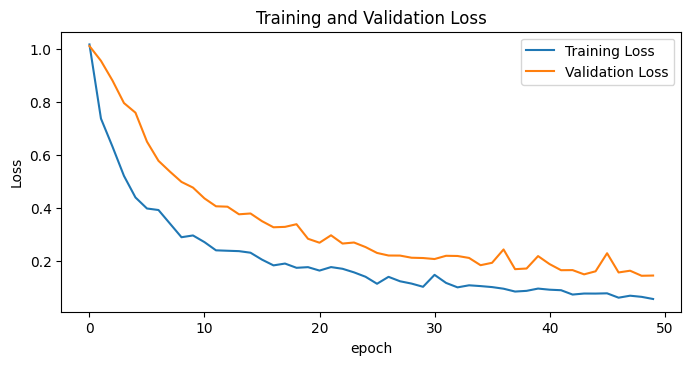

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()


1/1 [==============================] - 17s 17s/step


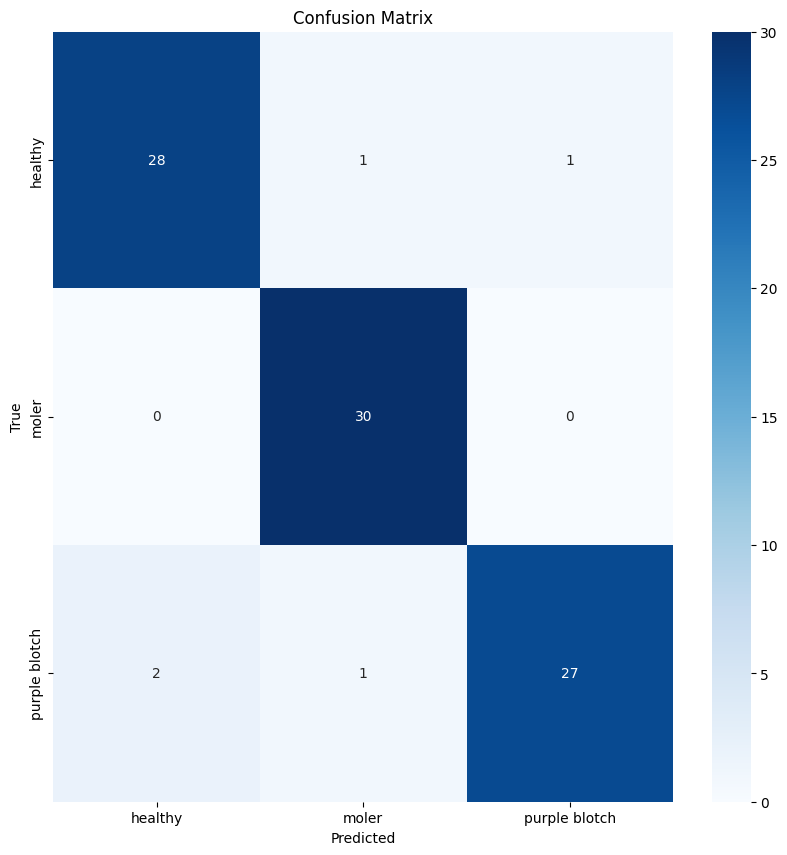

               precision    recall  f1-score   support

      healthy       0.93      0.93      0.93        30
        moler       0.94      1.00      0.97        30
purple blotch       0.96      0.90      0.93        30

     accuracy                           0.94        90
    macro avg       0.95      0.94      0.94        90
 weighted avg       0.95      0.94      0.94        90

Validation Loss: 0.1456
Validation Accuracy: 94.44%


In [ ]:
# Evaluate the model on the validation set
validation_loss, validation_accuracy = model.evaluate(validation_generator)

# Reset the validation generator
validation_generator.reset()

# Fetch and predict all images in the validation set
predictions = []
true_labels = []
for _ in range(len(validation_generator)):
    x_val, y_val = next(validation_generator)
    preds = model.predict(x_val)
    predictions.extend(np.argmax(preds, axis=1))
    true_labels.extend(y_val)

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predictions)
class_labels = list(validation_generator.class_indices.keys())

# Plot the confusion matrix
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print the classification report
print(classification_report(true_labels, predictions, target_names=class_labels))

print(f"Validation Loss: {validation_loss:.4f}")
print(f"Validation Accuracy: {validation_accuracy * 100:.2f}%")

In [ ]:
# Create a test data generator, which only rescales the images
test_datagen = ImageDataGenerator(rescale=1./255)

# Generate batches of test images
test_generator = test_datagen.flow_from_directory(
    'C:/Users/nisri/Downloads/capstone/sigma-onion-sensor/analyzeAI/Testing_ov5',
    target_size=(224, 224),
    batch_size=32,  # Adjust the batch size according to your needs
    class_mode='sparse',  # Ensure the class mode matches the one used during training
    shuffle=False  # Do not shuffle the data for testing; it's important for matching outputs with labels
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)

# Predict all images in the test set for detailed classification report
test_generator.reset()  # Resetting generator to ensure correct label matching
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get the true labels from the generator
true_classes = test_generator.classes

# Print the classification report including F1 score, precision, and recall
print(classification_report(true_classes, predicted_classes, target_names=test_generator.class_indices.keys()))

# Print accuracy and loss
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")



Found 60 images belonging to 3 classes.
2/2 [==============================] - 37s 17s/step
               precision    recall  f1-score   support

      healthy       0.77      0.50      0.61        20
        moler       1.00      1.00      1.00        20
purple blotch       0.63      0.85      0.72        20

     accuracy                           0.78        60
    macro avg       0.80      0.78      0.78        60
 weighted avg       0.80      0.78      0.78        60

Test Loss: 0.4704
Test Accuracy: 78.33%


In [ ]:
# Save the model
model.save('/content/drive/MyDrive/fix/ov5_VGG16.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
